# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [32]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [34]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [35]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [36]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.

 **Comentario:** 
- El dataset plans contiene información de los planes disponibles y tiene pocas filas.
- El dataset users contiene información demográfica y de registro de los clientes.
- El dataset usage registra el comportamiento real de uso de llamadas y mensajes.
- Se observan posibles valores faltantes y columnas de fecha que deben convertirse al formato datetime.

In [37]:
# revisar el número de filas y columnas de cada dataset
print('plans:', plans.shape)
print('users:', users.shape)
print('usage:', usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [38]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [39]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [40]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [41]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean() * 100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [42]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean() * 100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

Valores nulos
En users, las columnas con pocos valores nulos pueden imputarse o mantenerse dependiendo del contexto.
Si existe una columna con más del 80% de nulos, puede considerarse eliminarla.
En usage, los nulos en duration y length probablemente dependen del tipo de actividad (call o text), por lo que deben investigarse antes de imputar.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [43]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


Columna user_id

Los IDs parecen únicos y consistentes.

Columna age

Puede existir el valor sentinel -999, que representa un error o dato faltante.

In [44]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Columnas id y user_id

Los identificadores no presentan problemas aparentes.

Columnas duration y length

Existen valores nulos que dependen del tipo de actividad.

In [45]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()

city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



Columna city

Puede existir el sentinel ?, el cual debe reemplazarse por NA.

Columna plan

Solo deberían existir categorías válidas como Basic y Premium.

In [46]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

Columna type

Los tipos de actividad corresponden a llamadas (call) y mensajes (text).



Valores inválidos o sentinels

-Se identificaron valores inválidos y sentinels principalmente en el dataset users.
-En la columna age se encontró el valor -999, el cual no representa una edad válida y probablemente fue utilizado como código para indicar datos faltantes o errores de captura.

Acción recomendada: 

-Reemplazar estos valores por la mediana de edad, ya que es una medida robusta frente a valores extremos.
-En la columna city se detectó el valor "?", utilizado como placeholder para ciudades desconocidas o no registradas.

Acción recomendada: 
-Reemplazar "?" por pd.NA para tratarlo como valor faltante oficial.
-En las columnas de fecha (reg_date y date) podrían existir años fuera del rango esperado (posteriores a 2024).

Acción recomendada: 
-Convertir esas fechas a valores nulos (NaT) para evitar errores en el análisis temporal.
-En el dataset usage, los valores nulos en duration y length no parecen ser errores, ya que dependen del tipo de actividad:
-Las llamadas (call) tienen duración pero no longitud.
-Los mensajes (text) tienen longitud pero no duración.

Acción recomendada: 
-Mantener estos nulos porque representan un comportamiento esperado del negocio y no deben imputarse.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [47]:
# convertir fechas
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [48]:
# revisar años en reg_date
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

In [49]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

En reg_date...

Se observó que la mayoría de los registros pertenecen a años válidos dentro del periodo analizado. También se revisó si existían fechas fuera de rango, como años posteriores a 2024 o fechas inválidas generadas durante la conversión.

Las fechas que no pudieron convertirse correctamente fueron transformadas en NaT gracias al parámetro errors='coerce'. Además, cualquier fecha futura debe considerarse inconsistente y marcarse como valor nulo para evitar sesgos en el análisis temporal.

In [50]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En date...

Se observó que las fechas del dataset usage corresponden al historial de actividad de llamadas y mensajes de los usuarios. La mayoría de registros se encuentran dentro del rango esperado para el análisis.

También se revisó la existencia de años fuera de rango, como fechas posteriores a 2024, las cuales podrían representar errores de captura o inconsistencias en el sistema. Estas fechas deben marcarse como valores nulos (NaT) para evitar afectar el análisis temporal.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:


Durante la revisión de las columnas reg_date y date, se verificó si existían años fuera del rango esperado para el análisis. El proyecto trabaja con información registrada hasta el año 2024, por lo que cualquier fecha posterior debe considerarse inconsistente.

Sí pueden aparecer años imposibles o fuera de rango, como fechas futuras o fechas demasiado antiguas que no coincen con el contexto del negocio. Estos registros probablemente corresponden a errores de captura, problemas de formato o fallos durante la carga de datos.

¿Qué haría con ellas?
Convertir las fechas inválidas a valores nulos (NaT) para evitar errores en el análisis.
Mantener únicamente registros dentro del rango lógico del negocio.
Utilizar errors='coerce' durante la conversión a datetime para detectar automáticamente formatos incorrectos.
Evitar imputar fechas inventadas, ya que esto podría distorsionar los análisis temporales y segmentaciones.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [51]:
# calcular mediana excluyendo el sentinel
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# reemplazar sentinel
users['age'] = users['age'].replace(-999, age_mediana)

# verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [52]:
# reemplazar ? por valores nulos
users['city'] = users['city'].replace('?', pd.NA)

# verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [53]:
# marcar fechas futuras como nulas en users
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# marcar fechas futuras como nulas en usage
usage.loc[usage['date'].dt.year > 2024, 'date'] = pd.NaT

# verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [54]:
# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    normalize='index'
)

duration,False,True
type,,
call,1.000000,0.000000
text,0.000724,0.999276


In [55]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    normalize='index'
)

length,False,True
type,,
call,0.00067,0.99933
text,1.00000,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Se observó que los valores nulos en duration dependen directamente del tipo de actividad registrada. Cuando el tipo es text, la duración aparece vacía porque los mensajes no tienen duración.

De forma similar, los valores nulos en length aparecen principalmente cuando el tipo es call, ya que las llamadas no tienen longitud de mensaje.

Esto indica un patrón MAR (Missing At Random), donde la ausencia de datos depende de otra variable del dataset y no de un error aleatorio.

Acción recomendada
Mantener los valores nulos tal como están.
No imputar valores artificiales.
Considerar estos nulos como parte natural del modelo de negocio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [56]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

In [57]:
# Renombrar columnas

# observar resultado
usage_agg.columns = [
    'user_id',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [58]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [59]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [60]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

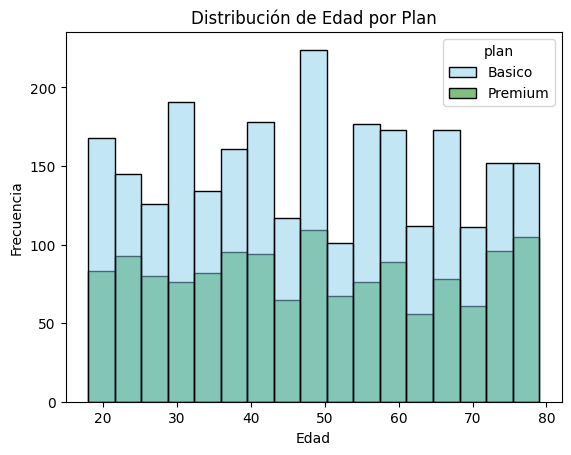

In [61]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
La mayoría de usuarios pertenece a edades jóvenes y adultas.
No se observan diferencias extremas entre planes.
La distribución es relativamente simétrica.

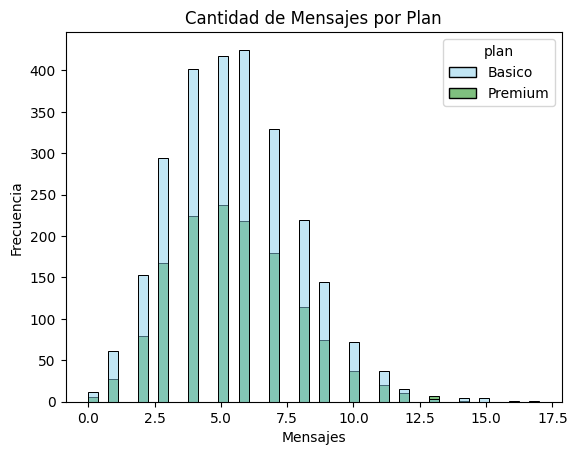

In [62]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de Mensajes por Plan')
plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
Los usuarios Premium muestran mayor uso de mensajes.
Existen pocos usuarios con consumos muy altos.
Distribución sesgada a la derecha.

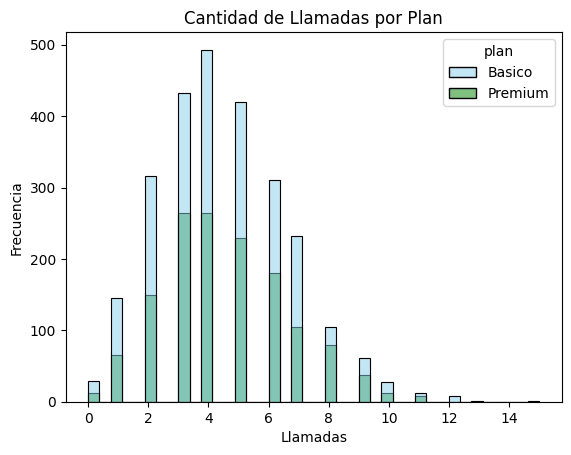

In [63]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de Llamadas por Plan')
plt.xlabel('Llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
Los usuarios Basic concentran consumos bajos.
Algunos usuarios realizan muchas más llamadas que el promedio.
Distribución sesgada a la derecha.

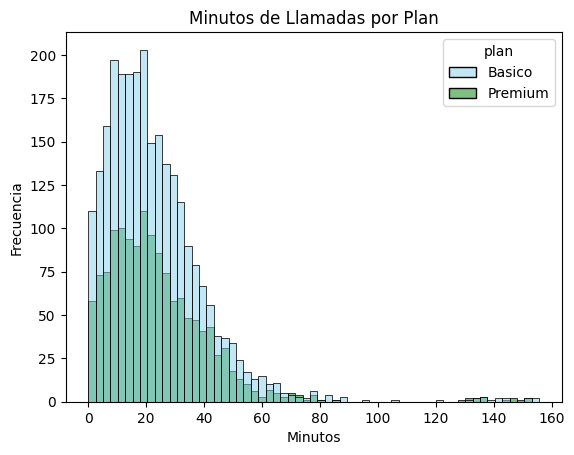

In [64]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Minutos de Llamadas por Plan')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
Los usuarios Premium concentran los mayores consumos.
Existen valores extremos altos.
Distribución claramente sesgada a la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

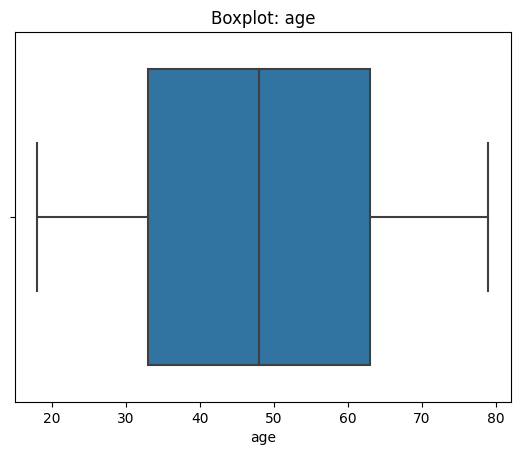

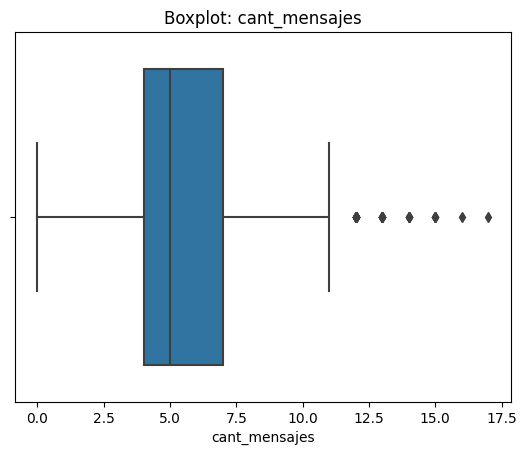

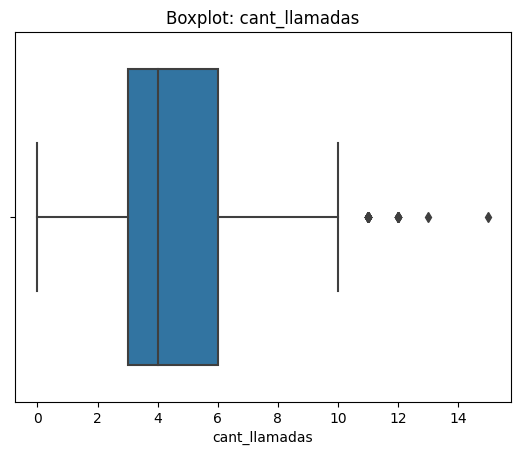

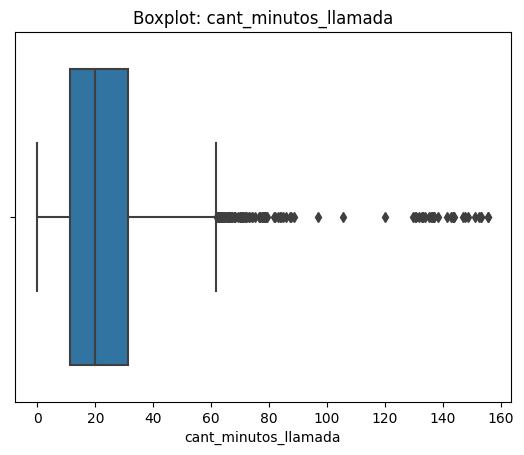

In [65]:
# Visualizando usando BoxPlot 

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:

    sns.boxplot(x=user_profile[col])

    plt.title(f'Boxplot: {col}')

    plt.show()

💡Insights: 

Age
Presenta pocos o ningún outlier importante.
cant_mensajes
Existen usuarios con niveles de mensajes muy superiores al promedio.
cant_llamadas
Se observan valores extremos altos.
cant_minutos_llamada
Existe una fuerte presencia de outliers.

In [66]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:

    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    print(f'Columna: {col}')
    print(f'Limite superior: {limite_superior}')
    print(f'Maximo real: {user_profile[col].max()}')
    print()

Columna: cant_mensajes
Limite superior: 11.5
Maximo real: 17.0

Columna: cant_llamadas
Limite superior: 10.5
Maximo real: 15.0

Columna: cant_minutos_llamada
Limite superior: 61.8575
Maximo real: 155.69



In [67]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

cant_mensajes
Mantener los outliers porque representan usuarios intensivos reales.
cant_llamadas
Mantener los outliers ya que forman parte del comportamiento natural de algunos clientes.
cant_minutos_llamada
Mantener los outliers porque ayudan a identificar clientes de alto valor o posibles patrones atípicos relevantes para el negocio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [68]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10),
    'grupo_uso'
] = 'Uso medio'

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [69]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [70]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[
    user_profile['age'] < 60,
    'grupo_edad'
] = 'Adulto'

user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [71]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

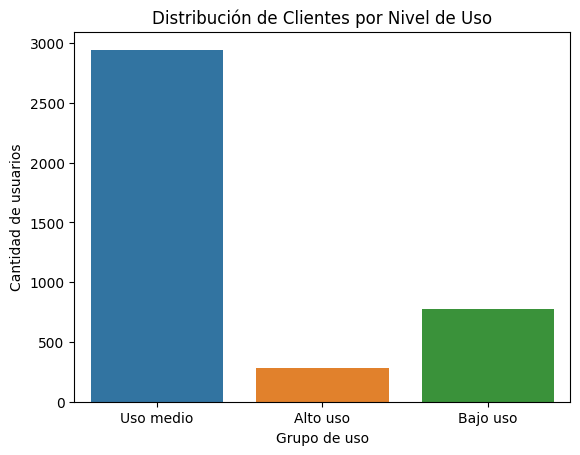

In [72]:
# Visualización de los segmentos por uso

sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de Clientes por Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ Problemas detectados en los datos

Durante la exploración y limpieza de datos se identificaron varios problemas de calidad que podían afectar el análisis:

En la columna age se encontraron valores sentinel -999, los cuales representaban edades inválidas. Estos registros correspondían a una pequeña proporción del dataset y fueron reemplazados por la mediana para evitar distorsionar las distribuciones.
En la columna city se detectó el valor "?" como placeholder de ciudades desconocidas. Estos registros fueron convertidos a valores nulos (NA) para tratarlos correctamente durante el análisis.
En las columnas de fecha (reg_date y date) aparecieron algunos años fuera del rango esperado, especialmente fechas posteriores a 2024. Estas filas fueron marcadas como NaT porque no representan datos válidos para el periodo analizado.
También se encontraron valores nulos en duration y length; sin embargo, el análisis mostró que dependían del tipo de actividad (call o text). Por ello, se concluyó que estos nulos eran esperados y no errores reales del dataset.

🔍 Segmentos por Edad

Se identificaron tres grandes segmentos demográficos:

Jóvenes (<30 años): presentan un mayor uso de mensajes y una interacción más frecuente con el servicio móvil. Este grupo muestra patrones de consumo más intensivos en comunicación rápida.
Adultos (30–59 años): representan la mayor parte de los clientes de ConnectaTel. Su comportamiento es más equilibrado entre llamadas y mensajes, con niveles de consumo medios y altos.
Adultos mayores (60+ años): muestran un uso más moderado tanto en llamadas como en mensajes. Este segmento parece utilizar el servicio de manera más conservadora.

📊 Segmentos por Nivel de Uso

A partir de la segmentación por comportamiento se identificaron tres grupos principales:

Bajo uso: usuarios con pocas llamadas y pocos mensajes. Generalmente corresponden a clientes ocasionales o con necesidades básicas de comunicación.
Uso medio: usuarios con actividad moderada y comportamiento estable. Representan una oportunidad importante para estrategias de fidelización y migración de plan.
Alto uso: usuarios con gran cantidad de llamadas, mensajes y minutos consumidos. Este segmento concentra a muchos clientes Premium y representa el grupo de mayor valor para ConnectaTel.

Los usuarios de alto uso parecen ser los más valiosos para la empresa porque generan mayor consumo del servicio y probablemente mayores ingresos mensuales.

➡️ Esto sugiere que el comportamiento de uso está directamente relacionado con el tipo de plan contratado y que existen oportunidades claras de personalización comercial.

📈 Patrones de uso extremo (Outliers)

El análisis mediante boxplots e IQR mostró la existencia de usuarios con consumos extremadamente altos en:

cantidad de mensajes,
cantidad de llamadas,
minutos totales de llamadas.

Estos outliers no necesariamente representan errores; en muchos casos corresponden a usuarios intensivos o clientes de alto valor.

Sin embargo, algunos patrones extremos podrían indicar:

posibles errores de captura,
uso corporativo no identificado,
compartición de líneas,
o incluso comportamientos sospechosos asociados a fraude.

Por esta razón, se recomienda monitorear continuamente estos perfiles.

💡 Recomendaciones

Crear planes intermedios dirigidos a usuarios de consumo medio para incentivar migraciones y aumentar ingresos.
Diseñar beneficios exclusivos para usuarios intensivos, como paquetes ilimitados o descuentos por fidelidad.
Implementar sistemas automáticos de detección de outliers para identificar posibles fraudes o anomalías operativas.
Personalizar campañas comerciales según edad y comportamiento de uso.
Promover upgrades desde planes Basic hacia Premium para usuarios que ya presentan patrones de alto consumo.
Desarrollar ofertas específicas para usuarios jóvenes enfocadas en mensajería y datos móviles, mientras que para adultos mayores podrían ofrecerse planes simplificados y económicos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`